# Two populations, one country

### What Portugal's 2025 GDP-per-capita revision does and does not mean

On 22 June 2026 Statistics Portugal (INE) published its *Estimativas de População Residente*
for 2025: **11,424,031** residents, on a new fully administrative basis, with 2021–2024
revised by the same method. Between 2021 and 2025 the resident population rose 824,914
people (7.8%), almost entirely through migration.

A widely shared inference followed, and it was pure arithmetic: more people dividing the same
output means GDP per capita must fall — from a preliminary **81.3%** of the EU average to
**77%**. A decade of convergence, undone by a statistical revision.

Testing that claim needs one question answered first, and it is a question of fact rather than
of economics:

> **Which population is the published GDP-per-capita index actually divided by?**

Portugal has two official population figures for 2025, and they differ by 5.6%:

| series | 2025 | what it is |
| --- | --- | --- |
| Eurostat `demo_gind` / INE | 11,405,627 | the revised demographic estimate |
| Eurostat `nama_10_pe` (POP_NC) | 10,804,160 | the **national-accounts** population |

Every published per-capita national-accounts figure divides by the second. The national
accounts have not been rebenchmarked onto the revision — they could not have been, since the
2025 accounts were compiled before INE published it in June 2026.

> **Bottom line.** The denominator correction **is** owed: on the revised resident population
> the 2025 index falls from 81.4 to **77.2**, reproducing the disputed figure. But that holds
> GDP fixed, which assumes the accounts already record everything the 601,467 uncounted
> residents produce — roughly **396,000 workers**' worth. If they recorded none of it, the
> index would instead be **81.7**.

That gap is governed by one quantity, **statistical capture**, and the uncomfortable finding of
this notebook is that **the available data cannot measure it**. The employment statistics share
the same un-rebenchmarked population base, so they are blind in exactly the place we need them
to see. What tilts the judgement is how GDP is compiled rather than anything in the series —
and that argument favours **77.2**, with 81.7 as the outer bound.

**How this is laid out**

| Part | Question |
| --- | --- |
| I | Which population is inside the published index? *(arithmetic, no modelling)* |
| II | Is the numerator on the same basis? The capture question |
| III | A Bayesian model for 2025 GDP, back-tested and scored |

## Part 0 — Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from pt_gdp_bayes.bayes import summarize_samples
from pt_gdp_bayes.data_sources import (
    default_cache_dir,
    fetch_eurostat_employment_rate,
    fetch_eurostat_national_accounts_employment,
    fetch_eurostat_national_accounts_population,
    fetch_eurostat_pps_inputs,
    fetch_oecd_employment_rate_by_birthplace,
    get_known_value,
    load_known_observations,
)
from pt_gdp_bayes.model import (
    backtest_gdp_model,
    capture_sensitivity_curve,
    estimate_gdp_posterior_samples,
    estimate_population_posterior_samples,
    pps_index_samples,
    score_against_outturn,
)
from pt_gdp_bayes.pipeline import ESTIMATION_START_YEAR, TARGET_YEAR, build_panel
from pt_gdp_bayes.reconciliation import (
    assess_correction_claim,
    compare_population_bases,
    derive_purchasing_power_parity,
    employment_absorbed_revision,
    employment_rate_excess_over_peers,
    implied_missing_workers,
    population_inside_index,
)

CACHE = default_cache_dir(PROJECT_ROOT)
N_SAMPLES = 20_000

# Validated categorical palette (light surface). Slots follow entities and are never
# recycled: BLUE = the revised demographic / resident population, ORANGE = the
# national-accounts basis and the article's claim, AQUA = realised published values.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d9d8d3"

plt.rcParams.update({
    "figure.figsize": (11, 5.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlesize": 12,
    "axes.titlelocation": "left", "axes.titleweight": "semibold", "axes.titlepad": 12,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "font.size": 10,
})
pd.set_option("display.max_columns", 100)


def summarise(samples, *, scale=1.0, unit="", decimals=2, label="value"):
    "Format a posterior summary (mean/median/sd/90% interval) as a tidy table."
    stats = summarize_samples(samples)
    order = ["mean", "median", "sd", "q5", "q95"]
    return pd.DataFrame({label: {k: f"{stats[k] / scale:,.{decimals}f}{unit}" for k in order}})


print(f"Target year {TARGET_YEAR} | euro-era estimation window from {ESTIMATION_START_YEAR}")
print(f"Cached series: {len(list(CACHE.glob('*.csv')))} under {CACHE.relative_to(PROJECT_ROOT)}")

Target year 2025 | euro-era estimation window from 1999
Cached series: 24 under data\raw


### Anchors

Official figures and the article's own numbers, each carrying its source. The INE values come
from the *Estimativas de População Residente 2025* release of 22 June 2026. Note
`migrant_working_age_share`: **86.1%** of foreign-national residents are aged 15–64, against
64.3% of the population as a whole. That is observed, not assumed, and it matters in Part II.

In [2]:
known = load_known_observations(PROJECT_ROOT / "data" / "known_observations.csv")


def anchor(name: str) -> float:
    return get_known_value(known, name, TARGET_YEAR)


REVISED_POPULATION = anchor("resident_population")
PRELIMINARY_INDEX = anchor("preliminary_gdp_pc_pps_index")
CORRECTION_FACTOR = anchor("population_correction_factor")
ARTICLE_INDEX = anchor("article_corrected_gdp_pc_pps_index")

known[["variable", "value", "unit", "source"]]

,variable,value,unit,source
0,resident_population,1.142403e+07,persons,"INE, Estimativas de População Residente 2025 (..."
1,resident_population_2021,1.059912e+07,persons,"INE, Estimativas de População Residente 2025 (..."
2,foreign_residents,1.597539e+06,persons,"INE, Estimativas de População Residente 2025 (..."
3,foreign_resident_share,1.400000e-01,share,"INE, Estimativas de População Residente 2025 (..."
4,migrant_working_age_share,8.610000e-01,share,"INE, Estimativas de População Residente 2025 (..."
5,total_working_age_share,6.430000e-01,share,"INE, Estimativas de População Residente 2025 (..."
6,real_gdp_growth,1.900000e-02,decimal,INE Press Release 706214887
7,preliminary_gdp_pc_pps_index,8.130000e+01,EU27_2025_100,Article citing European Commission AMECO May 2025
8,population_correction_factor,1.056000e+00,ratio,Article calculations
9,article_corrected_gdp_pc_pps_index,7.700000e+01,EU27_2025_100,Article calculations


---
# Part I — Which population is inside the published index?

No modelling here. The index is a definition, so this is arithmetic on published series.

## 1. Portugal has two official populations

INE's revision, published June 2026, moved the *demographic* estimate onto an administrative
basis and lifted it by roughly 600,000 people from 2022 onward. The *national accounts* carry
their own population series (`nama_10_pe`, "national concept"), compiled alongside GDP. It has
not moved.

In [3]:
panel = build_panel(cache_dir=CACHE)
pps_inputs = fetch_eurostat_pps_inputs("PT", cache_dir=CACHE)
na_population = fetch_eurostat_national_accounts_population("PT", cache_dir=CACHE)

bases = compare_population_bases(
    pps_inputs, revised_anchor=REVISED_POPULATION, anchor_year=TARGET_YEAR
)
recent = bases[bases["year"].between(2019, TARGET_YEAR)]
recent.assign(
    na_population=lambda d: d["na_population"].map("{:,.0f}".format),
    demographic_population=lambda d: d["demographic_population"].map("{:,.0f}".format),
    gap=lambda d: d["gap"].map("{:,.0f}".format),
    gap_pct=lambda d: d["gap_pct"].round(2),
)[["year", "na_population", "demographic_population", "gap", "gap_pct"]]

,year,na_population,demographic_population,gap,gap_pct
59,2019,"10,354,450","10,354,446",-4,-0.00
60,2020,"10,384,850","10,373,508","-11,342",-0.11
61,2021,"10,407,710","10,407,707",-3,-0.00
62,2022,"10,468,870","10,764,411","295,541",2.82
63,2023,"10,578,170","11,067,026","488,856",4.62
64,2024,"10,694,680","11,295,785","601,105",5.62
65,2025,"10,804,160","11,405,627","601,467",5.57


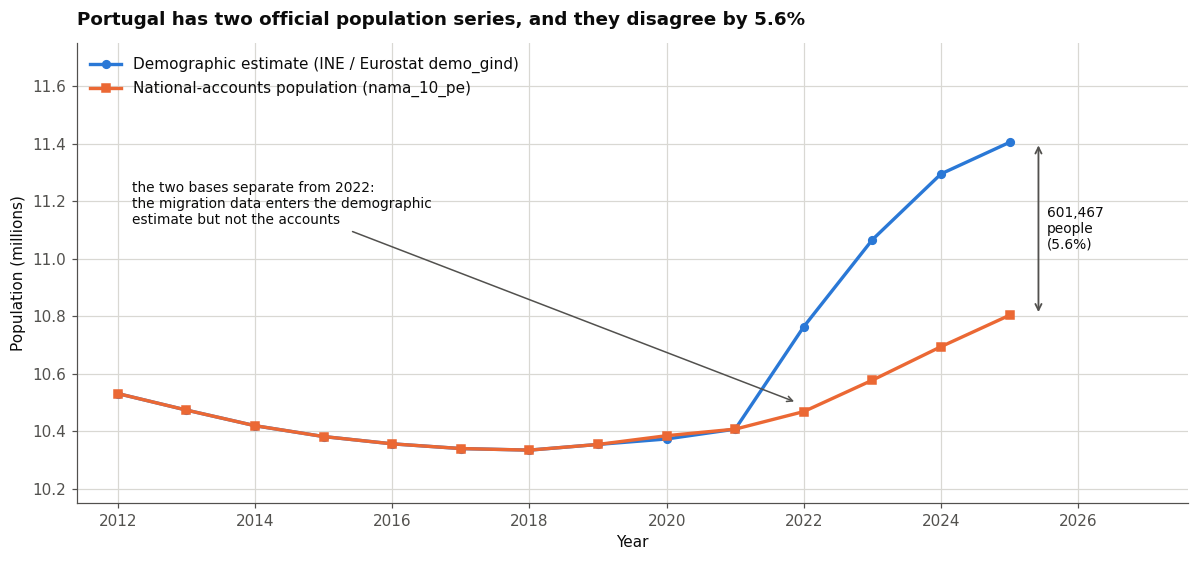

In [4]:
fig, ax = plt.subplots()
plot = bases[bases["year"].between(2012, TARGET_YEAR)].dropna(subset=["na_population"])

ax.plot(plot["year"], plot["demographic_population"] / 1e6, "-", color=BLUE, lw=2.2,
        marker="o", ms=5, label="Demographic estimate (INE / Eurostat demo_gind)")
ax.plot(plot["year"], plot["na_population"] / 1e6, "-", color=ORANGE, lw=2.2,
        marker="s", ms=5, label="National-accounts population (nama_10_pe)")

ax.annotate("the two bases separate from 2022:\nthe migration data enters the demographic\nestimate but not the accounts",
            xy=(2021.9, 10.50), xytext=(2012.2, 11.12), fontsize=9, color=INK,
            arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 1})

# Vertical span between the two series in the target year, labelled.
gap_x = TARGET_YEAR + 0.42
na_2025 = float(plot.loc[plot["year"] == TARGET_YEAR, "na_population"].iloc[0]) / 1e6
demo_2025 = float(plot.loc[plot["year"] == TARGET_YEAR, "demographic_population"].iloc[0]) / 1e6
ax.annotate("", xy=(gap_x, demo_2025), xytext=(gap_x, na_2025),
            arrowprops={"arrowstyle": "<->", "color": MUTED, "lw": 1.2})
ax.text(gap_x + 0.12, (na_2025 + demo_2025) / 2,
        f"{plot['gap'].iloc[-1]:,.0f}\npeople\n(5.6%)", fontsize=9, color=INK, va="center")

ax.set(title="Portugal has two official population series, and they disagree by 5.6%",
       xlabel="Year", ylabel="Population (millions)",
       xlim=(2011.4, 2027.6), ylim=(10.15, 11.75))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Neither series is wrong.** They measure the same concept on different vintages. INE published
the revision on **22 June 2026**; the 2025 annual national accounts were compiled before that,
so they could not have used it. The accounts will be rebenchmarked at a future benchmark
revision, and until then the two coexist.

That is the entire mechanism behind the public argument. The question is which one the
published index divides by.

## 2. Recovering the population inside the index — without assuming it

The index is defined as

$$\text{index} = \frac{\text{GDP} / \text{population} / \text{PPP}}{\text{EU average GDP per capita in PPS}} \times 100$$

Eurostat publishes GDP per capita in euro directly (`CP_EUR_HAB`), so the population inside it
is simply

$$\text{population} = \frac{\text{GDP}}{\text{GDP per capita in euro}}$$

No assumption about which series was used enters anywhere.

In [5]:
target = pps_inputs.loc[pps_inputs["year"] == TARGET_YEAR].iloc[0]
GDP = float(target["gdp_meur"]) * 1e6
PPP = derive_purchasing_power_parity(
    gdp_pc_eur=float(target["gdp_pc_eur"]), gdp_pc_pps=float(target["gdp_pc_pps"])
)
EU_REFERENCE = float(target["eu_gdp_pc_pps"])
PUBLISHED_INDEX = float(target["gdp_pc_pps"]) / EU_REFERENCE * 100

recovered = population_inside_index(gdp=GDP, gdp_pc_eur=float(target["gdp_pc_eur"]))

print(f"Published GDP {TARGET_YEAR}                : {GDP/1e9:,.1f} bn EUR")
print(f"Published GDP per capita             : {target['gdp_pc_eur']:,.0f} EUR")
print(f"-> population inside the index       : {recovered:,.0f}")
print()
print(f"National-accounts population         : {target['na_population']:,.0f}  "
      f"(difference {recovered/target['na_population'] - 1:+.3%})")
print(f"Demographic (revised) population     : {target['population_avg']:,.0f}  "
      f"(difference {recovered/target['population_avg'] - 1:+.2%})")
print()
print(f"Derived PPP                          : {PPP:.5f} EUR per PPS")
print(f"Published index                      : {PUBLISHED_INDEX:.2f}")

Published GDP 2025                : 306.7 bn EUR
Published GDP per capita             : 28,390 EUR
-> population inside the index       : 10,804,847

National-accounts population         : 10,804,160  (difference +0.006%)
Demographic (revised) population     : 11,405,627  (difference -5.27%)

Derived PPP                          : 0.83932 EUR per PPS
Published index                      : 81.38


The recovered population matches the national-accounts series to within 0.01%, and sits 5.3%
below the demographic one. **The published index divides by the un-rebenchmarked population.**

### A trap worth naming

There is an inviting shortcut here that silently destroys the test: deriving the PPP as
`GDP / population / gdp_pc_pps` using whichever population you had in mind, then "recovering"
the population from the index. That is circular — it returns the assumption you fed in, with
every appearance of being a measurement.

In [6]:
gdp_pc_pps = float(target["gdp_pc_pps"])
rows = []
for label, assumed in [("national-accounts population", float(target["na_population"])),
                       ("demographic population", float(target["population_avg"]))]:
    circular_ppp = GDP / assumed / gdp_pc_pps
    circular_recovery = GDP / (circular_ppp * gdp_pc_pps)
    rows.append({
        "population assumed when deriving PPP": f"{assumed:,.0f}",
        "PPP it implies": round(circular_ppp, 5),
        "population 'recovered'": f"{circular_recovery:,.0f}",
        "matches the assumption?": np.isclose(circular_recovery, assumed),
    })

print("Circular route - the answer is whatever you assumed:")
display(pd.DataFrame(rows))
print(f"\nNon-circular route (PPP from two published per-capita figures): "
      f"{recovered:,.0f} regardless of any assumption.")
print(f"Only one of these is consistent with the published price level index "
      f"(~82.5 in 2024): PPP {PPP:.3f} -> {PPP*100:.1f}.")

Circular route - the answer is whatever you assumed:


,population assumed when deriving PPP,PPP it implies,population 'recovered',matches the assumption?
0,"10,804,160",0.83937,"10,804,160",True
1,"11,405,627",0.79511,"11,405,627",True



Non-circular route (PPP from two published per-capita figures): 10,804,847 regardless of any assumption.
Only one of these is consistent with the published price level index (~82.5 in 2024): PPP 0.839 -> 83.9.


## 3. Verdict: the correction is owed

Substituting the revised resident population, holding GDP fixed.

In [7]:
verdict = assess_correction_claim(
    pps_inputs, year=TARGET_YEAR,
    quoted_index=PRELIMINARY_INDEX, revised_population=float(target["population_avg"]),
)
print(verdict.summary())
print()
print(f"correction_is_owed = {verdict.correction_is_owed}")
print(f"index on the revised population = {verdict.denominator_only_index:.2f}"
      f"   |   the article claims {ARTICLE_INDEX:.1f}")

2025: the quoted index 81.30 is computed on a population of 10,804,847, which is 5.3% BELOW the revised 11,405,627. The national accounts have not been rebenchmarked. Holding GDP fixed, the index on the revised population is 77.02 — but that holds only if measured GDP already captures the extra residents' output, which is a separate question.

correction_is_owed = True
index on the revised population = 77.02   |   the article claims 77.0


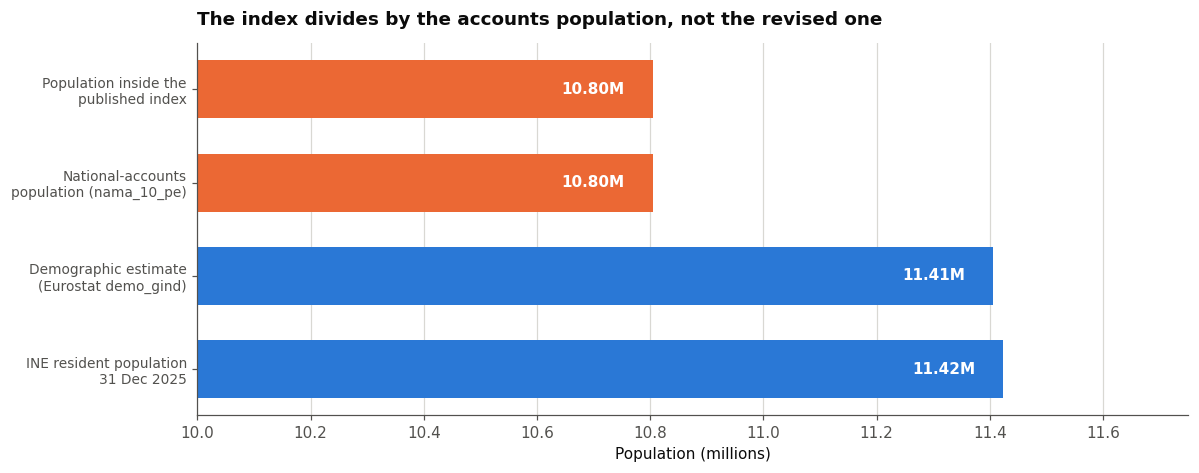

In [8]:
scenarios = pd.DataFrame([
    {"label": "Population inside the\npublished index", "value": recovered, "color": ORANGE},
    {"label": "National-accounts\npopulation (nama_10_pe)", "value": float(target["na_population"]),
     "color": ORANGE},
    {"label": "Demographic estimate\n(Eurostat demo_gind)", "value": float(target["population_avg"]),
     "color": BLUE},
    {"label": "INE resident population\n31 Dec 2025", "value": REVISED_POPULATION, "color": BLUE},
])

fig, ax = plt.subplots(figsize=(11, 4.4))
y = np.arange(len(scenarios))[::-1]
ax.barh(y, scenarios["value"] / 1e6, color=scenarios["color"], height=0.62)
for yi, value in zip(y, scenarios["value"]):
    ax.text(value / 1e6 - 0.05, yi, f"{value/1e6:.2f}M", va="center", ha="right",
            color="white", fontweight="semibold", fontsize=10)
ax.set_yticks(y)
ax.set_yticklabels(scenarios["label"], fontsize=9)
ax.set(title="The index divides by the accounts population, not the revised one",
       xlabel="Population (millions)", xlim=(10.0, 11.75))
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

So the article's arithmetic is right: on the revised resident population the 2025 index is
**77.2**, not 81.4. The 5.6% correction factor it uses is very close to the true ratio between
the two population bases.

**But this is a bound, not the answer.** It holds GDP fixed while changing the population — and
the reason the two bases differ is that the accounts have not absorbed ~600,000 residents. If
the accounts have not counted those people, the question of whether they counted their *output*
is wide open. That is Part II, and it is where the real uncertainty lives.

---
# Part II — Is the numerator on the same basis as the denominator?

A denominator-only correction assumes measured GDP already contains everything the uncounted
residents produce. That assumption deserves a name and a number.

> **Statistical capture** ($\varphi$) — the share of the uncounted residents' output that the
> national accounts already record.

At $\varphi = 1$ the accounts are complete and only the denominator moves: index **77.2**.
At $\varphi = 0$ the accounts missed their output entirely, GDP is revised up, and the two
effects largely cancel.

Capture is not zero. GDP is compiled from production-side sources — VAT turnover, corporate
accounts, social-security payroll — which record a firm's output regardless of whether the
demographic count knows its staff exist. But it is not one either, or the accounts' own
employment count would have kept pace with its own population base. It has not.

In [9]:
migrant_employment = fetch_oecd_employment_rate_by_birthplace("PRT", cache_dir=CACHE)
na_employment = fetch_eurostat_national_accounts_employment("PT", cache_dir=CACHE)

migrant_rate = float(
    migrant_employment.loc[migrant_employment["year"] >= 2022, "foreign_born"].mean()
) / 100.0
activity_rate = anchor("migrant_activity_rate")
working_age_share = anchor("migrant_working_age_share")

UNCOUNTED = float(target["population_avg"]) - float(target["na_population"])
MISSING_WORKERS = implied_missing_workers(
    extra_residents=UNCOUNTED,
    working_age_share=working_age_share,
    activity_rate=activity_rate,
    employment_rate=migrant_rate / activity_rate,
)
employed = float(na_employment.loc[na_employment["year"] == TARGET_YEAR, "na_employment"].iloc[0])
OUTPUT_PER_EMPLOYED = GDP / employed

pd.Series({
    "residents the accounts have not counted": f"{UNCOUNTED:,.0f}",
    "of them aged 15-64 (INE, 86.1%)": f"{UNCOUNTED * working_age_share:,.0f}",
    "foreign-born employment rate (OECD 2022-24)": f"{migrant_rate:.1%}",
    "=> workers the accounts may be missing": f"{MISSING_WORKERS:,.0f}",
    "national-accounts employment 2025": f"{employed:,.0f}",
    "output per employed person": f"{OUTPUT_PER_EMPLOYED:,.0f} EUR",
}).to_frame("value")

,value
residents the accounts have not counted,"601,467"
"of them aged 15-64 (INE, 86.1%)","517,863"
foreign-born employment rate (OECD 2022-24),76.5%
=> workers the accounts may be missing,"395,994"
national-accounts employment 2025,"5,396,960"
output per employed person,"56,837 EUR"


## 4. Can the employment data identify capture?

It is tempting to think so, and the first look is encouraging. Employment must be compared with
the population base the accounts actually use — comparing it with the *demographic* population
would mix two bases that differ by 5.6% and produce movements that are pure artefact. On the
accounts' own base, employment has grown considerably faster than population, which looks like
the accounts picking up workers their benchmark does not know about.

That reading does not survive scrutiny, and the rest of this section is about why.

In [10]:
employment_check = employment_absorbed_revision(
    na_employment=na_employment, na_population=na_population, years=(2019, TARGET_YEAR)
)
employment_check.assign(
    na_employment=lambda d: d["na_employment"].map("{:,.0f}".format),
    na_population=lambda d: d["na_population"].map("{:,.0f}".format),
    employment_population_ratio=lambda d: (d["employment_population_ratio"] * 100).round(2),
    employment_growth_pct=lambda d: d["employment_growth_pct"].round(2),
    population_growth_pct=lambda d: d["population_growth_pct"].round(2),
)

,year,na_employment,na_population,employment_population_ratio,employment_growth_pct,population_growth_pct
0,2019,"4,983,270","10,354,450",48.13,NaN,NaN
1,2020,"4,884,370","10,384,850",47.03,-1.98,0.29
2,2021,"4,952,930","10,407,710",47.59,1.40,0.22
3,2022,"5,137,900","10,468,870",49.08,3.73,0.59
4,2023,"5,238,180","10,578,170",49.52,1.95,1.04
5,2024,"5,275,310","10,694,680",49.33,0.71,1.10
6,2025,"5,396,960","10,804,160",49.95,2.31,1.02


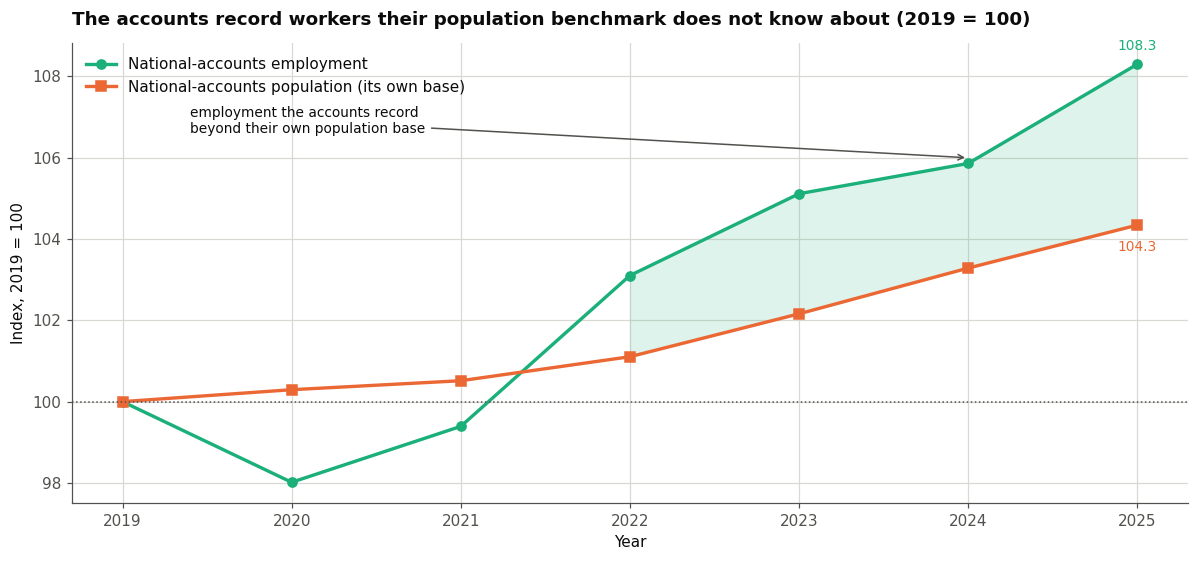

In [11]:
# Indexed to a common base so both series share one axis.
base_row = employment_check[employment_check["year"] == 2019].iloc[0]
idx = employment_check.assign(
    employment=lambda d: d["na_employment"] / base_row["na_employment"] * 100,
    population=lambda d: d["na_population"] / base_row["na_population"] * 100,
)

fig, ax = plt.subplots()
ax.plot(idx["year"], idx["employment"], "-", color=AQUA, lw=2.2, marker="o", ms=6,
        label="National-accounts employment")
ax.plot(idx["year"], idx["population"], "-", color=ORANGE, lw=2.2, marker="s", ms=6,
        label="National-accounts population (its own base)")
ax.fill_between(idx["year"], idx["population"], idx["employment"],
                where=idx["employment"] >= idx["population"], color=AQUA, alpha=0.14, lw=0)
ax.axhline(100, color=MUTED, lw=1, ls=":")

last = idx.iloc[-1]
ax.annotate(f"{last['employment']:.1f}", (last["year"], last["employment"]),
            textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=AQUA)
ax.annotate(f"{last['population']:.1f}", (last["year"], last["population"]),
            textcoords="offset points", xytext=(0, -17), ha="center", fontsize=9, color=ORANGE)
ax.annotate("employment the accounts record\nbeyond their own population base",
            xy=(2024.0, 106.0), xytext=(2019.4, 106.6), fontsize=9, color=INK,
            arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 1})

ax.set(title="The accounts record workers their population benchmark does not know about (2019 = 100)",
       xlabel="Year", ylabel="Index, 2019 = 100")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Why that reading fails

Two problems, and either is fatal on its own.

**The employment series cannot see the uncounted residents.** National-accounts employment is
built largely from the Labour Force Survey, which is grossed up on its *own* population
benchmark — the same un-rebenchmarked one. If ~600,000 residents are outside that benchmark,
their work is outside the employment count by construction. The count and the base share a
blind spot, so their ratio says nothing about what is in the blind spot.

**Employment rates rose all over Europe.** Portugal's employment rate went from 69.8% to 73.9%
between 2019 and 2025 — but that is a post-COVID recovery common to the continent, and it has
nothing to do with Portuguese population benchmarks. Any absorption signal has to be an
*excess* over that trend.

In [12]:
peer_rates = None
for geo in ["PT", "EU27_2020", "ES", "IE"]:
    frame = fetch_eurostat_employment_rate(geo, cache_dir=CACHE).rename(
        columns={"employment_rate_pct": geo}
    )
    peer_rates = frame if peer_rates is None else peer_rates.merge(frame, on="year", how="outer")
peer_rates = peer_rates.dropna().sort_values("year").reset_index(drop=True)

excess = employment_rate_excess_over_peers(
    peer_rates, country="PT", peers=["EU27_2020", "ES", "IE"],
    base_year=2019, target_year=TARGET_YEAR,
)
print("Employment rate, aged 15-64 (%), published:")
display(peer_rates[peer_rates["year"] >= 2019].set_index("year"))
print(f"\nChange 2019-{TARGET_YEAR}, Portugal against comparators:")
display(excess.round(2))

Employment rate, aged 15-64 (%), published:


,PT,EU27_2020,ES,IE
year,,,,
2019,69.8,68.1,63.3,69.4
2020,68.3,67.1,60.9,66.5
2021,69.6,68.3,62.6,69.8
2022,71.4,69.8,64.3,73.3
2023,72.4,70.4,65.3,74.0
2024,72.8,70.7,66.1,74.5
2025,73.9,71.0,67.0,74.6



Change 2019-2025, Portugal against comparators:


,peer,country_change_pp,peer_change_pp,excess_pp
0,EU27_2020,4.1,2.9,1.2
1,ES,4.1,3.7,0.4
2,IE,4.1,5.2,-1.1


**There is no reliable excess.** Portugal's 4.1pp rise is 1.2pp above the EU27, 0.4pp above
Spain — and 1.1pp *below* Ireland. Spain and Ireland are the right comparators precisely
because they also absorbed large migration inflows over the period. Portugal's employment-rate
increase sits inside the normal European range.

Converted to workers, the excess spans roughly +82,000 (EU27 benchmark) to *negative* (Ireland
benchmark), against the ~396,000 the uncounted residents imply. That is not an estimate of
capture; it is noise around zero.

> **So the employment data cannot identify capture.** An earlier version of this notebook
> reported a capture range of 0.24–0.64 derived from exactly the excess-employment calculation
> above, without controlling for the European trend. That number was an artefact and has been
> withdrawn.

## 5. What actually bears on capture: how GDP is compiled

Since the data cannot settle it, the question becomes a methodological one, and it has
arguments on both sides.

**For high capture** — GDP is compiled primarily from *production-side* sources: VAT turnover,
corporate tax filings, structural business statistics. A restaurant's revenue enters those
records regardless of whether the demographic count knows its waiters exist. For output produced
in the formal sector, the population benchmark is simply not in the measurement chain. National
accounts also carry an explicit exhaustiveness adjustment for undeclared work.

**For low capture** — some components *are* population-benchmarked: imputed rents on
owner-occupied dwellings, parts of household final consumption, and non-market output. Those
components would be understated on a population base that is 5.6% short.

The balance of these favours high capture, because the population-benchmarked components are a
minority of GDP. But that is a reasoned judgement about compilation practice, not a measurement,
and this notebook will not dress it up as one.

## 6. The index across the whole range of capture

In [13]:
population_result = estimate_population_posterior_samples(
    panel, target_year=TARGET_YEAR, population_col="resident_population",
    observed_population=float(target["population_avg"]), n_samples=N_SAMPLES, random_seed=7,
)

capture_curve = capture_sensitivity_curve(
    capture_values=np.linspace(0.0, 1.0, 21),
    extra_residents=UNCOUNTED,
    baseline_output_per_employed=OUTPUT_PER_EMPLOYED,
    working_age_share=working_age_share,
    participation_rate=activity_rate,
    employment_rate=migrant_rate / activity_rate,
    productivity_relative=anchor("migrant_relative_productivity"),
    measured_gdp_samples=np.full(N_SAMPLES, GDP),
    population_samples=population_result.samples,
    purchasing_power_parity=PPP,
    reference_gdp_pc_pps=EU_REFERENCE,
    n_samples=N_SAMPLES,
)
capture_curve[capture_curve["statistical_capture"].isin([0.0, 0.25, 0.5, 0.75, 1.0])].round(2)

,statistical_capture,extra_gdp_bn_eur,pps_median,pps_q5,pps_q95
0,0.00,18.12,81.73,79.83,83.61
5,0.25,13.56,80.57,79.11,82.07
10,0.50,9.07,79.41,78.33,80.69
15,0.75,4.52,78.22,77.37,79.51
20,1.00,0.00,77.16,76.70,77.63


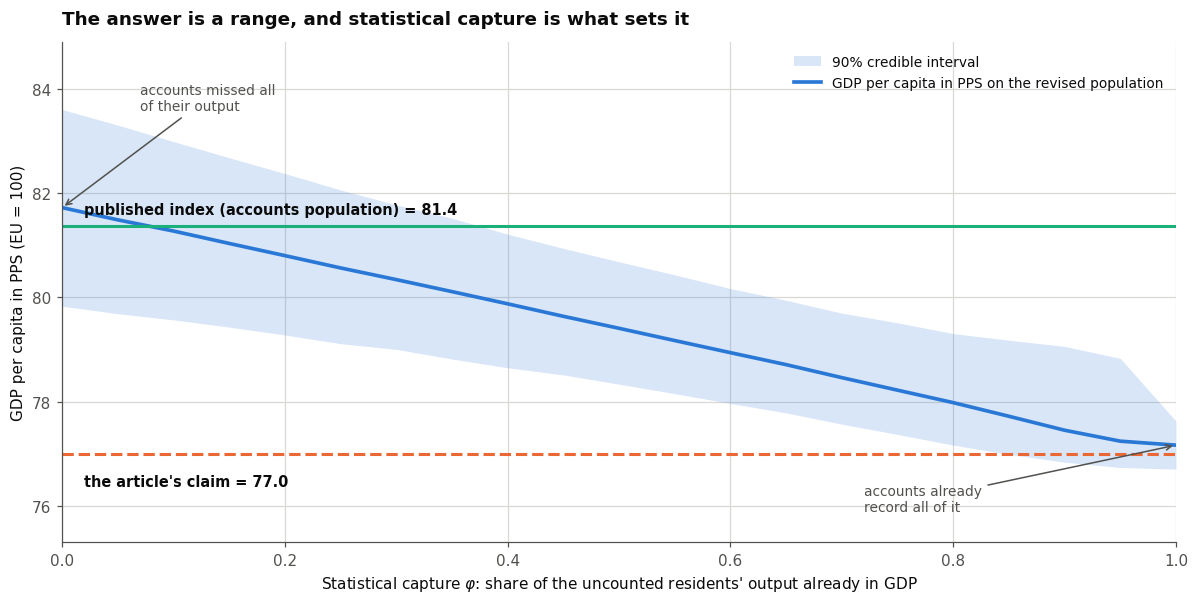

Full range: 77.2 at phi=1 to 81.7 at phi=0.


In [14]:
fig, ax = plt.subplots(figsize=(11, 5.6))
ax.fill_between(capture_curve["statistical_capture"], capture_curve["pps_q5"],
                capture_curve["pps_q95"], alpha=0.18, color=BLUE, lw=0,
                label="90% credible interval")
ax.plot(capture_curve["statistical_capture"], capture_curve["pps_median"], "-",
        color=BLUE, lw=2.4, label="GDP per capita in PPS on the revised population")

ax.axhline(PUBLISHED_INDEX, color=AQUA, lw=2.0, ls="-")
ax.text(0.02, PUBLISHED_INDEX + 0.22, f"published index (accounts population) = {PUBLISHED_INDEX:.1f}",
        fontsize=9.5, color=INK, fontweight="semibold")
ax.axhline(ARTICLE_INDEX, color=ORANGE, lw=2.0, ls="--")
ax.text(0.02, ARTICLE_INDEX - 0.62, f"the article's claim = {ARTICLE_INDEX:.1f}",
        fontsize=9.5, color=INK, fontweight="semibold")

ax.annotate("accounts missed all\nof their output", xy=(0.0, capture_curve["pps_median"].iloc[0]),
            xytext=(0.07, 83.6), fontsize=9, color=MUTED,
            arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 1})
ax.annotate("accounts already\nrecord all of it", xy=(1.0, capture_curve["pps_median"].iloc[-1]),
            xytext=(0.72, 75.9), fontsize=9, color=MUTED,
            arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 1})

ax.set(title="The answer is a range, and statistical capture is what sets it",
       xlabel=r"Statistical capture $\varphi$: share of the uncounted residents' output already in GDP",
       ylabel="GDP per capita in PPS (EU = 100)", xlim=(0, 1), ylim=(75.3, 84.9))
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Full range: {capture_curve['pps_median'].iloc[-1]:.1f} at phi=1 "
      f"to {capture_curve['pps_median'].iloc[0]:.1f} at phi=0.")

**Reading this chart.** Both ends are assumptions, not findings. The article sits at the far
right ($\varphi = 1$: the accounts recorded every euro those residents produced). The earlier
labour-absorption rebuttal of it sits at the far left ($\varphi = 0$: they recorded none).

**The data does not locate a point on this line.** That is the honest result. The employment
statistics share the population blind spot, so they cannot see into it, and Portugal's
employment-rate rise is unremarkable against its peers. What tilts the judgement toward the
right-hand side is the argument in section 5 — that GDP is compiled mainly from production-side
records in which the population benchmark plays no part.

So **77.2 is the best single reading, and 81.7 the outer bound** on the possibility that the
accounts missed the output as well as the people. Anyone quoting a number from this chart is
choosing a capture value, whether or not they say so — including the article, which chooses 1
silently.

---
# Part III — A model for 2025 GDP, and a score against the outturn

Everything above holds GDP at its published value. The remaining question is whether that
value is itself well estimated — which, now that 2025 is published, can be checked rather than
asserted.

The model regresses nominal GDP growth on its own lag, population growth and deflator growth,
then combines it with the direct signal from realised real growth. **Population enters on the
national-accounts basis**, because that is the series GDP is vintage-consistent with; the
resident population is modelled separately as the per-capita denominator.

In [15]:
gdp_history = panel.dropna(subset=["gdp_current_eur"]).set_index("year")
nominal_growth = np.log(gdp_history["gdp_current_eur"]).diff() * 100
deflator = panel.dropna(subset=["gdp_deflator_pct"]).set_index("year")["gdp_deflator_pct"]

eras = []
for lo, hi, name in [(1961, 1985, "1961-1985 (pre-accession)"),
                     (1986, 1998, "1986-1998 (EEC, pre-euro)"),
                     (1999, 2024, "1999-2024 (euro era)")]:
    g = nominal_growth[(nominal_growth.index >= lo) & (nominal_growth.index <= hi)]
    d = deflator[(deflator.index >= lo) & (deflator.index <= hi)]
    eras.append({"era": name, "nominal_gdp_growth_mean_pct": g.mean(),
                 "nominal_gdp_growth_sd_pp": g.std(),
                 "gdp_deflator_mean_pct": d.mean(), "gdp_deflator_sd_pp": d.std()})
pd.DataFrame(eras).round(2)

,era,nominal_gdp_growth_mean_pct,nominal_gdp_growth_sd_pp,gdp_deflator_mean_pct,gdp_deflator_sd_pp
0,1961-1985 (pre-accession),15.53,6.67,12.03,9.13
1,"1986-1998 (EEC, pre-euro)",12.12,5.41,8.85,4.97
2,1999-2024 (euro era),3.68,4.12,2.57,1.72


Portuguese nominal series break decisively at euro entry, so the estimation window starts in
1999. Fitting across the break both biases the deflator prediction upward and inflates its
residual variance enough to let a badly specified regression outvote the real-growth signal.

In [16]:
accounts_population = float(target["na_population"])
gdp_windows = {}
for label, start in [("Full history (1960-)", None),
                     (f"Euro era ({ESTIMATION_START_YEAR}-)", ESTIMATION_START_YEAR)]:
    gdp_windows[label] = estimate_gdp_posterior_samples(
        panel, target_year=TARGET_YEAR,
        population_samples=np.full(N_SAMPLES, accounts_population),
        population_col="na_population", known_real_gdp_growth=anchor("real_gdp_growth"),
        estimation_start_year=start, n_samples=N_SAMPLES, random_seed=11,
    )
gdp_result = gdp_windows[f"Euro era ({ESTIMATION_START_YEAR}-)"]

pd.DataFrame([
    {"estimation window": label,
     "deflator draw median %": np.median(r.deflator_growth_samples) * 100,
     "deflator draw sd pp": r.deflator_growth_samples.std() * 100,
     "GDP median bn EUR": np.median(r.gdp_samples) / 1e9,
     "GDP sd bn EUR": r.gdp_samples.std() / 1e9}
    for label, r in gdp_windows.items()
]).round(2)

,estimation window,deflator draw median %,deflator draw sd pp,GDP median bn EUR,GDP sd bn EUR
0,Full history (1960-),6.43,5.96,314.89,18.87
1,Euro era (1999-),2.38,1.84,302.34,5.63


## 6. Out-of-sample back-test

In [17]:
backtests = {
    label: backtest_gdp_model(
        panel, holdout_years=list(range(2010, TARGET_YEAR)), population_col="na_population",
        estimation_start_year=start, credible_mass=0.90, n_samples=6_000,
    )
    for label, start in [("Full history", None), ("Euro era", ESTIMATION_START_YEAR)]
}
backtest = backtests["Euro era"]

pd.DataFrame([
    {"estimation window": label,
     "coverage of 90% interval": f"{bt['in_interval'].mean():.0%}",
     "mean abs error": f"{bt['pct_error'].abs().mean():.1f}%",
     "mean interval width": f"{((bt['q_high']-bt['q_low'])/bt['actual']*100).mean():.1f}%"}
    for label, bt in backtests.items()
])

,estimation window,coverage of 90% interval,mean abs error,mean interval width
0,Full history,80%,6.0%,20.1%
1,Euro era,67%,3.9%,10.2%


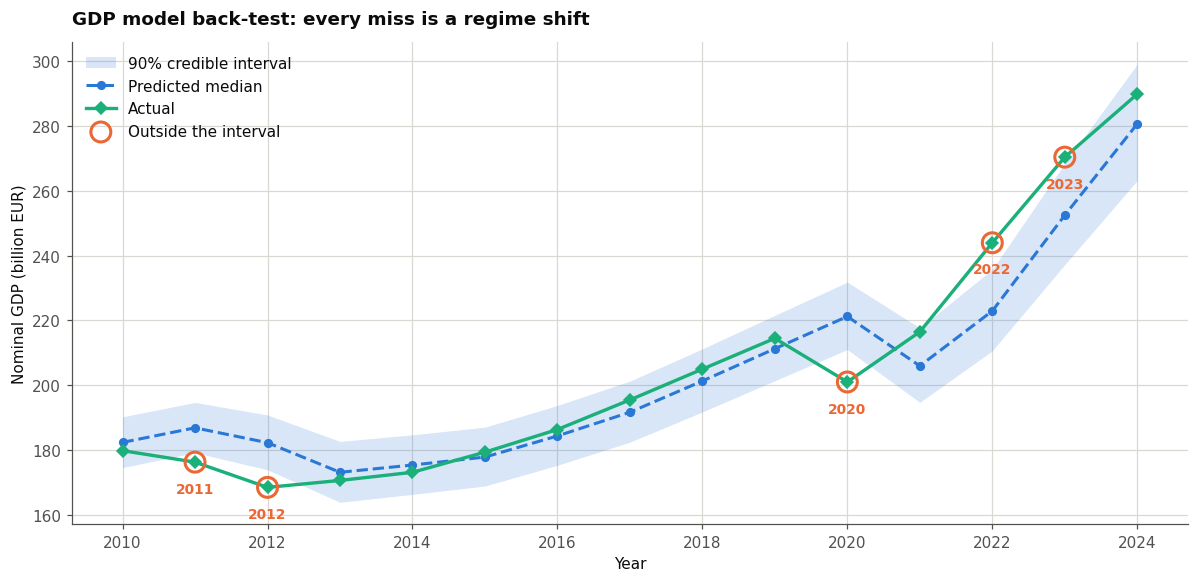

All years        : 67% coverage, 3.9% mean absolute error
Excl. shock years: 80% coverage, 2.8% mean absolute error (n=10)


In [18]:
fig, ax = plt.subplots(figsize=(11, 5.4))
ax.fill_between(backtest["year"], backtest["q_low"] / 1e9, backtest["q_high"] / 1e9,
                alpha=0.18, color=BLUE, lw=0, label="90% credible interval")
ax.plot(backtest["year"], backtest["predicted_median"] / 1e9, "--", color=BLUE, lw=2,
        marker="o", ms=5, label="Predicted median")
ax.plot(backtest["year"], backtest["actual"] / 1e9, "-", color=AQUA, lw=2.2,
        marker="D", ms=6, label="Actual")

missed = backtest[~backtest["in_interval"]]
ax.scatter(missed["year"], missed["actual"] / 1e9, s=170, facecolors="none",
           edgecolors=ORANGE, lw=2, zorder=6, label="Outside the interval")
for _, r in missed.iterrows():
    ax.annotate(f"{r['year']}", (r["year"], r["actual"] / 1e9), textcoords="offset points",
                xytext=(0, -20), ha="center", fontsize=9, color=ORANGE, fontweight="semibold")

ax.set(title="GDP model back-test: every miss is a regime shift",
       xlabel="Year", ylabel="Nominal GDP (billion EUR)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

shock_years = {2011, 2012, 2013, 2020, 2021}
calm = backtest[~backtest["year"].isin(shock_years)]
print(f"All years        : {backtest['in_interval'].mean():.0%} coverage, "
      f"{backtest['pct_error'].abs().mean():.1f}% mean absolute error")
print(f"Excl. shock years: {calm['in_interval'].mean():.0%} coverage, "
      f"{calm['pct_error'].abs().mean():.1f}% mean absolute error (n={len(calm)})")

Restricting to the euro era cut mean absolute error from 6.0% to 3.9% and halved the interval
width — but coverage *fell* from 80% to 67% against a 90% target. The model became sharper and,
in the process, overconfident.

The misses are not random: 2011–12 (sovereign-debt crisis and austerity), 2020 (COVID) and
2022–23 (the inflation surge, which a deflator model fitted on twenty years of 2% inflation
could not anticipate). Every one is a regime shift. Outside them the model runs at 80% coverage
and 2.8% error.

## 7. Scoring the 2025 estimate — and being precise about what is being scored

One honesty check before reading the number. The model is handed INE's announced 2025 **real**
growth as an input, so this is a **conditional nowcast**, not an out-of-sample forecast: given
real growth, the model has to supply the deflator. Its error is therefore almost entirely
deflator error, and it should not be quoted as evidence that the model forecasts GDP well.

The unconditional out-of-sample evidence is the back-test in section 6, which withholds the
contemporaneous real-growth signal entirely.

Nominal GDP 2025: median 302.3 bn EUR vs actual 306.7 bn EUR (-1.4%), inside the credible interval [293.3, 311.8] bn EUR, PIT 0.78


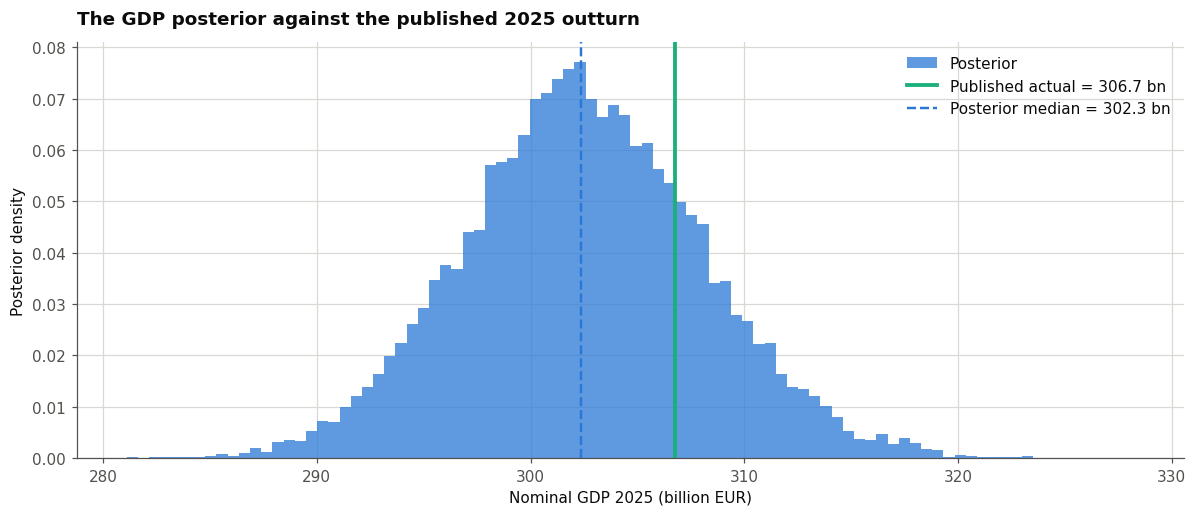

In [19]:
score = score_against_outturn(gdp_result.gdp_samples, GDP)
print(score.summary(label="Nominal GDP 2025", scale=1e9, unit=" bn EUR"))

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.hist(gdp_result.gdp_samples / 1e9, bins=90, density=True, alpha=0.75, color=BLUE,
        label="Posterior")
ax.axvline(GDP / 1e9, color=AQUA, lw=2.5, label=f"Published actual = {GDP/1e9:.1f} bn")
ax.axvline(score.median / 1e9, color=BLUE, lw=1.6, ls="--",
           label=f"Posterior median = {score.median/1e9:.1f} bn")
ax.set(title="The GDP posterior against the published 2025 outturn",
       xlabel="Nominal GDP 2025 (billion EUR)", ylabel="Posterior density")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The posterior median lands about 1.4% below the outturn, inside the 90% interval, with a PIT
near 0.8 — the truth sits in the upper tail. Decomposed, the miss is the deflator: the model
drew 2.4% against a realised 3.9%. That is the same weakness the back-test exposed, since a
deflator model fitted on the low-inflation euro era under-reads the 2022–25 surge.

So the honest reading is narrow: **conditional on real growth, the model's deflator is about
1.5pp low**. It confirms the published GDP is not obviously mis-estimated on its own terms,
and it says nothing at all about the capture question, which concerns the *coverage* of the
accounts rather than the accuracy of what they cover.

## 8. A calibration fix that did not work

In [20]:
import pt_gdp_bayes.model as model_module

original_fit = model_module.fit_bayesian_linear_regression
rows = []
try:
    for alpha0, beta0 in [(3.0, 0.001), (2.0, 0.001), (1.5, 0.001), (1.0, 0.001), (0.5, 0.0005)]:
        def patched(X, y, *, prior_mean=None, prior_variance=10.0, alpha0=2.0, beta0=1.0,
                    ridge=1e-8, _a=alpha0, _b=beta0):
            return original_fit(X, y, prior_mean=prior_mean, prior_variance=prior_variance,
                                alpha0=_a, beta0=_b, ridge=ridge)
        model_module.fit_bayesian_linear_regression = patched
        bt = backtest_gdp_model(
            panel, holdout_years=list(range(2010, TARGET_YEAR)), population_col="na_population",
            estimation_start_year=ESTIMATION_START_YEAR, n_samples=6_000,
        )
        rows.append({"alpha0": alpha0, "beta0": beta0,
                     "coverage": f"{bt['in_interval'].mean():.0%}",
                     "mean abs error": f"{bt['pct_error'].abs().mean():.1f}%",
                     "mean interval width":
                         f"{((bt['q_high']-bt['q_low'])/bt['actual']*100).mean():.1f}%"})
finally:
    model_module.fit_bayesian_linear_regression = original_fit

pd.DataFrame(rows)

,alpha0,beta0,coverage,mean abs error,mean interval width
0,3.0,0.0010,67%,3.9%,10.2%
1,2.0,0.0010,67%,3.9%,10.7%
2,1.5,0.0010,67%,3.9%,11.0%
3,1.0,0.0010,67%,3.9%,11.3%
4,0.5,0.0005,67%,3.9%,11.3%


The back-test under-covers, so the obvious suspect is a too-tight inverse-gamma prior on the
residual variance. Loosening it by a factor of six widens the intervals by about one percentage
point and leaves coverage **completely unmoved at 67%**.

The under-coverage is therefore not overconfidence in a variance parameter. The misses are
6–10% errors driven by events no prior widening anticipates, and covering them would require
intervals so wide they carry no information. Reported rather than tuned away; `alpha0 = 3.0`
stands.

## 9. Summary

In [21]:
capture_index = {
    row["statistical_capture"]: row["pps_median"]
    for _, row in capture_curve.iterrows()
}
summary = pd.DataFrame([
    {"quantity": "Published index (accounts population, 10.80M)",
     "value": f"{PUBLISHED_INDEX:.1f}"},
    {"quantity": "Index on revised population, full capture (phi = 1)",
     "value": f"{capture_curve['pps_median'].iloc[-1]:.1f}"},
    {"quantity": "Portugal employment-rate rise 2019-2025 vs EU27 / ES / IE",
     "value": "+1.2pp / +0.4pp / -1.1pp -> no absorption signal"},
    {"quantity": "Index on revised population, zero capture (phi = 0)",
     "value": f"{capture_curve['pps_median'].iloc[0]:.1f}"},
    {"quantity": "Residents the accounts have not counted",
     "value": f"{UNCOUNTED:,.0f}"},
    {"quantity": "Workers those residents imply",
     "value": f"{MISSING_WORKERS:,.0f}"},
    {"quantity": "GDP 2025 posterior median vs published",
     "value": f"{score.median/1e9:.1f} vs {GDP/1e9:.1f} bn EUR ({score.pct_error:+.1f}%)"},
])
summary

,quantity,value
0,"Published index (accounts population, 10.80M)",81.4
1,"Index on revised population, full capture (phi...",77.2
2,Portugal employment-rate rise 2019-2025 vs EU2...,+1.2pp / +0.4pp / -1.1pp -> no absorption signal
3,"Index on revised population, zero capture (phi...",81.7
4,Residents the accounts have not counted,"601,467"
5,Workers those residents imply,"395,994"
6,GDP 2025 posterior median vs published,302.3 vs 306.7 bn EUR (-1.4%)


---
# Conclusions

**The denominator correction is owed.** Portugal's published GDP per capita in PPS for 2025
(81.4) divides by the national-accounts population of 10.80 million, not by the revised
resident population of 11.41 million. Substituting the revised figure and holding GDP fixed
gives **77.2**. The article's arithmetic is right and its correction factor is close to the
true ratio between the two bases.

**But holding GDP fixed is an assumption, not a neutral step.** The two population bases differ
precisely *because* the accounts have not absorbed some 601,000 residents. Assuming the
accounts nonetheless captured all of those residents' output — roughly 396,000 workers' worth —
is a substantive claim about statistical coverage, and it is the claim that produces 77.

**The available data cannot settle that claim.** This is the finding that took the longest to
reach and is the least comfortable. National-accounts employment has grown faster than the
national-accounts population base, which looks like evidence of absorption until two things are
noticed: the employment count is grossed up on the *same* un-rebenchmarked base, so it is blind
in exactly the place we need it to see; and Portugal's employment-rate rise of 4.1pp since 2019
is unremarkable beside the EU27 (+2.9pp), Spain (+3.7pp) and Ireland (+5.2pp). Controlling for
that common trend leaves no absorption signal at all.

**What tilts the judgement is compilation practice, not the series.** GDP is built mainly from
production-side records — VAT turnover, corporate filings, structural business statistics — in
which a firm's output appears regardless of whether the demographic count knows its staff
exist. A minority of components are genuinely population-benchmarked (imputed rents, parts of
household consumption, non-market output) and those would be understated. On balance capture is
high, which puts the answer near **77.2**, with **81.7** as the outer bound if the accounts
missed the output as thoroughly as they missed the people.

**What resolves it.** Nothing here is permanent. When the national accounts are rebenchmarked
onto the administrative population, numerator and denominator will share a basis and capture
will stop mattering. Until then, any single number quoted for 2025 is a choice of capture in
disguise — including the article's, which chooses 1 without saying so, and which happens to be
the defensible choice.

### The methodological lesson

Three passes at this question went wrong before it came out right, in three different
directions, and the failures rhyme.

The first corrected a per-capita statistic without establishing which denominator was already
inside it. The second recovered that denominator through a **circular derivation** — computing
a conversion factor from an assumed population, then "recovering" the population from it, which
returns the assumption wearing the costume of a measurement. The recovery has to run through
two independently published figures, here GDP per capita in euro and GDP per capita in PPS, so
that no population enters the derivation at all.

The third attributed a **Europe-wide employment recovery** to Portuguese statistical absorption,
producing a confident capture range that a single comparison against Spain and Ireland
dissolved. A trend that shows up in every comparable country is not evidence about one country's
statistical system.

The common thread is that each error produced a *more* precise-looking answer than the truth
supported. Precision is the thing to distrust first.

**Reconstruct a published statistic before correcting it, and check that any signal you find is
absent from the controls.** If you cannot recover a statistic's inputs from published data, you
do not yet know what you are adjusting.

### Key takeaways

- Portugal has **two official 2025 populations**, 10.80M (national accounts) and 11.41M
  (demographic), and the published per-capita index uses the first.
- The denominator correction **is owed**; on the revised population the index is **77.2** if
  GDP is held fixed, against 81.7 if the accounts missed the output entirely.
- **Statistical capture is not identified by the data.** The employment statistics share the
  population blind spot, and Portugal's employment-rate rise is ordinary beside its peers.
- The judgement rests on **how GDP is compiled**; production-side sourcing argues for high
  capture and therefore for the lower end.
- Recover a statistic's denominator from **independently published figures**, and distrust an
  answer that looks more precise than its evidence.